In [ ]:


# ----- IMPORT LIBRARIES -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, mean_absolute_error, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [7]:
# ----- LOAD DATASET -----
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    low_memory=False,
    na_values=["?"]
)

print("Missing Values:\n", df.isnull().sum())

missing_percentage = (df.isnull().sum() / len(df) * 100).round(1)
print("\nPercentage of missing values:")
print(missing_percentage)

Missing Values:
 Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Percentage of missing values:
Date                     0.0
Time                     0.0
Global_active_power      1.3
Global_reactive_power    1.3
Voltage                  1.3
Global_intensity         1.3
Sub_metering_1           1.3
Sub_metering_2           1.3
Sub_metering_3           1.3
dtype: float64


In [8]:
# ----- DATA CLEANING -----
df.dropna(inplace=True)

print("Number of duplicated rows:", df.duplicated().sum())
df = df.drop_duplicates()

# Combine Date and Time into one Datetime column
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df['Hour']    = df['Datetime'].dt.hour
df['Day']     = df['Datetime'].dt.day
df['Month']   = df['Datetime'].dt.month
df['Weekday'] = df['Datetime'].dt.dayofweek
df.drop(['Date', 'Time'], axis=1, inplace=True)

print("\nData types:")
print(df.dtypes)
print("\nDimensions:", df.shape)
print("\nStatistical Summary:\n", df.describe())

Number of duplicated rows: 0


C:\Users\Abdullah\AppData\Local\Temp\ipykernel_6100\3619866008.py:8: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])



Data types:
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
Datetime                 datetime64[us]
Hour                              int32
Day                               int32
Month                             int32
Weekday                           int32
dtype: object

Dimensions: (2049280, 12)

Statistical Summary:
        Global_active_power  Global_reactive_power       Voltage  \
count         2.049280e+06           2.049280e+06  2.049280e+06   
mean          1.091615e+00           1.237145e-01  2.408399e+02   
min           7.600000e-02           0.000000e+00  2.232000e+02   
25%           3.080000e-01           4.800000e-02  2.389900e+02   
50%           6.020000e-01           1.000000e-01  2.410100e+02   
75%           1.528000e+00           1.94

In [9]:
# ----- OUTLIER CAPPING (IQR Method) -----
Q1 = df['Global_active_power'].quantile(0.25)
Q3 = df['Global_active_power'].quantile(0.75)
IQR = Q3 - Q1

lowerbound = Q1 - 1.5 * IQR
upperbound = Q3 + 1.5 * IQR

df['Global_active_power'] = np.clip(df['Global_active_power'], lowerbound, upperbound)

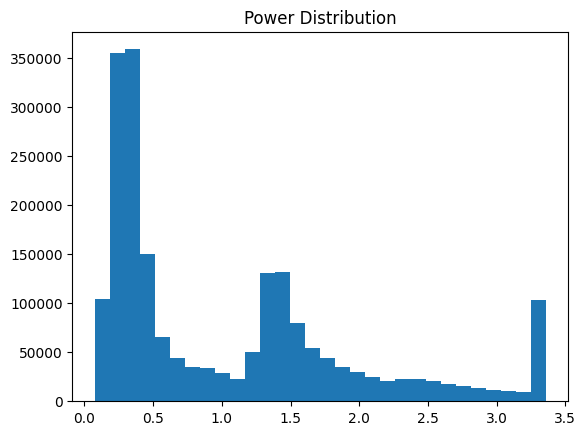

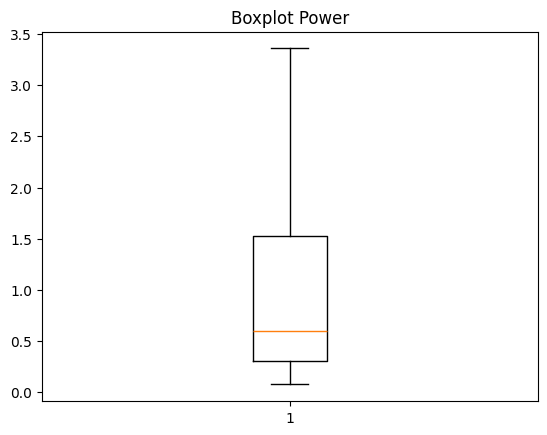

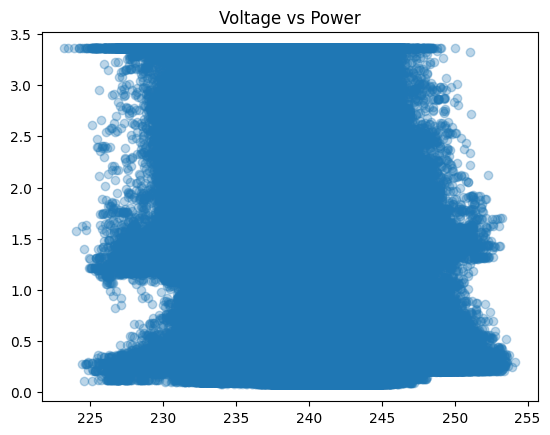

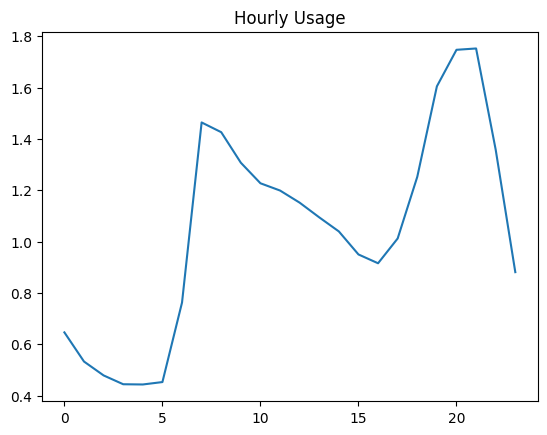

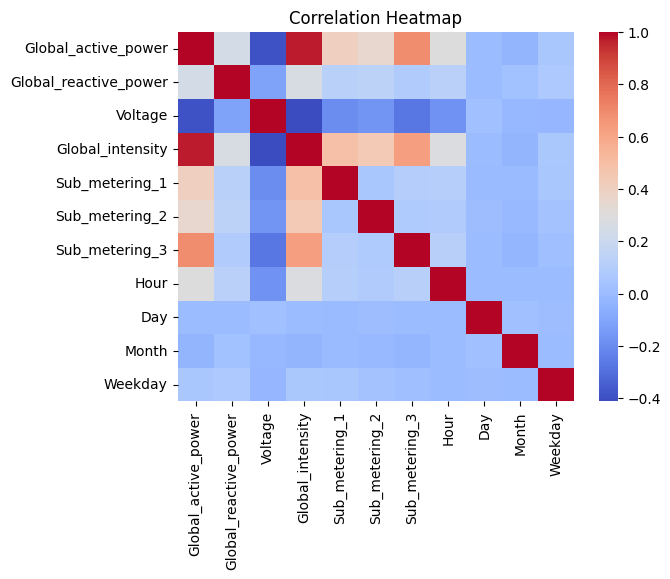

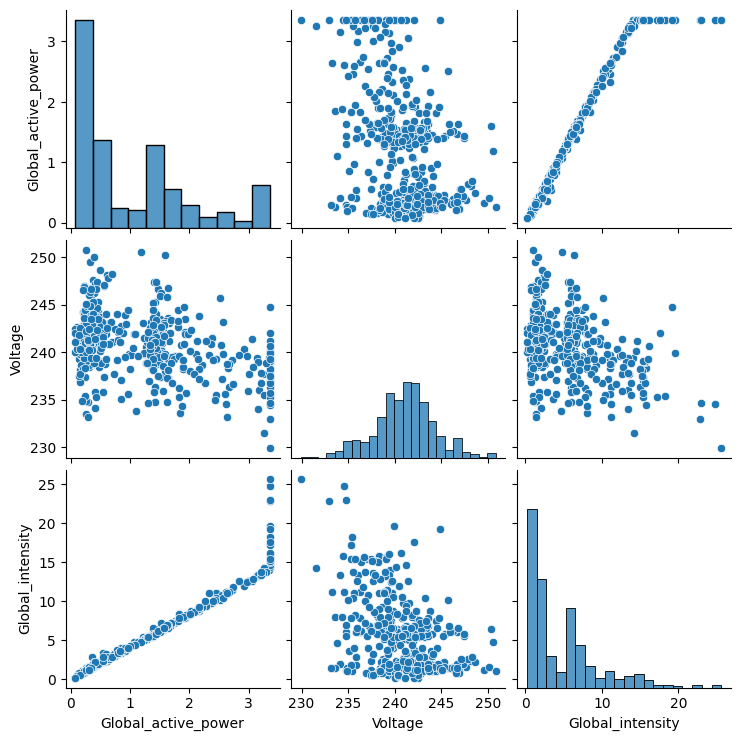

In [10]:
# ----- VISUALIZATIONS -----

# Histogram
plt.hist(df['Global_active_power'], bins=30)
plt.title("Power Distribution")
plt.show()

# Boxplot
plt.boxplot(df['Global_active_power'])
plt.title("Boxplot Power")
plt.show()

# Scatter plot
plt.scatter(df['Voltage'], df['Global_active_power'], alpha=0.3)
plt.title("Voltage vs Power")
plt.show()

# Hourly usage
hourly = df.groupby('Hour')['Global_active_power'].mean()
plt.plot(hourly)
plt.title("Hourly Usage")
plt.show()

# Correlation Heatmap
sns.heatmap(df.drop(columns=['Datetime']).corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(df[['Global_active_power','Voltage','Global_intensity']].sample(500))
plt.show()

In [11]:
# ----- PREPARE FEATURES AND TARGET -----
X = df.drop(['Global_active_power', 'Datetime'], axis=1)
y = df['Global_active_power']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# -----------------------------------------------
#          MODEL 1: LINEAR REGRESSION
# -----------------------------------------------

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Evaluation
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("----- Linear Regression Results -----")
print(f"MAE  : {lr_mae:.4f}")
print(f"RMSE : {lr_rmse:.4f}")
print(f"R2   : {lr_r2:.4f}")

# Sample predictions
lr_results = pd.DataFrame({"Actual": y_test.values, "Predicted": lr_pred})
print("\nSample Predictions:")
print(lr_results.head(10))

─── Linear Regression Results ───
MAE  : 0.0884
RMSE : 0.1984
R2   : 0.9531

Sample Predictions:
   Actual  Predicted
0   1.502   1.536931
1   0.374   0.458176
2   0.620   0.686938
3   0.280   0.316097
4   1.372   1.364844
5   0.284   0.396058
6   0.196   0.282127
7   2.234   2.265376
8   0.486   0.497320
9   1.842   1.814427


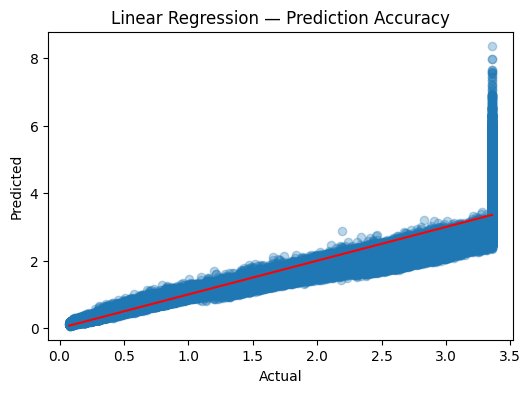

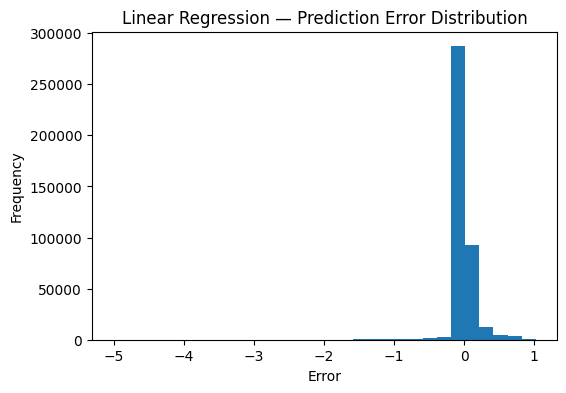

In [13]:
# Linear Regression — Actual vs Predicted
plt.figure(figsize=(6, 4))
plt.scatter(y_test, lr_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression — Prediction Accuracy")
plt.show()

# Error Distribution
lr_errors = y_test.values - lr_pred
plt.figure(figsize=(6, 4))
plt.hist(lr_errors, bins=30)
plt.title("Linear Regression — Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [14]:
# -----------------------------------------------
#       MODEL 2: RANDOM FOREST REGRESSOR
# -----------------------------------------------

# Sample 20% of training data to speed up training
X_train_sample = X_train.sample(frac=0.2, random_state=42)
y_train_sample = y_train[X_train_sample.index]

# n_estimators=50 (trees), max_depth limits tree size, n_jobs=-1 uses all CPU cores
rf_model = RandomForestRegressor(n_estimators=50, max_depth=15, n_jobs=-1, random_state=42)
rf_model.fit(X_train_sample, y_train_sample)
rf_pred = rf_model.predict(X_test)

In [15]:
# ----- RANDOM FOREST EVALUATION -----

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("----- Random Forest Regressor Results -----")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R2   : {rf_r2:.4f}")

# Sample predictions
rf_results = pd.DataFrame({"Actual": y_test.values, "Predicted": rf_pred})
print("\nSample Predictions:")
print(rf_results.head(10))

─── Random Forest Regressor Results ───
MAE  : 0.0154
RMSE : 0.0287
R2   : 0.9990

Sample Predictions:
   Actual  Predicted
0   1.502   1.542549
1   0.374   0.367032
2   0.620   0.633611
3   0.280   0.286985
4   1.372   1.380078
5   0.284   0.309396
6   0.196   0.181565
7   2.234   2.238757
8   0.486   0.464593
9   1.842   1.817622


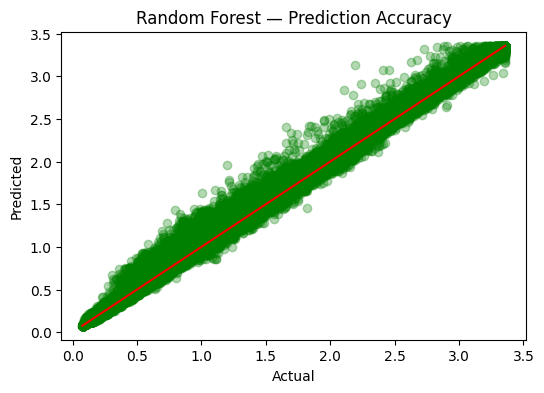

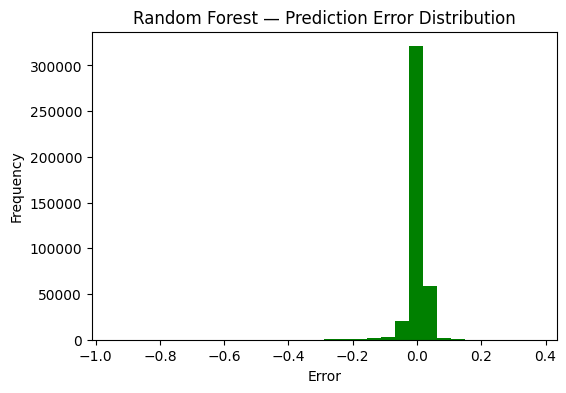

In [16]:
# Random Forest — Actual vs Predicted
plt.figure(figsize=(6, 4))
plt.scatter(y_test, rf_pred, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest — Prediction Accuracy")
plt.show()

# Error Distribution
rf_errors = y_test.values - rf_pred
plt.figure(figsize=(6, 4))
plt.hist(rf_errors, bins=30, color='green')
plt.title("Random Forest — Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

Feature Importances:
Global_intensity         0.998339
Global_reactive_power    0.000521
Voltage                  0.000357
Sub_metering_1           0.000252
Sub_metering_3           0.000150
Hour                     0.000104
Month                    0.000090
Day                      0.000073
Sub_metering_2           0.000073
Weekday                  0.000040
dtype: float64


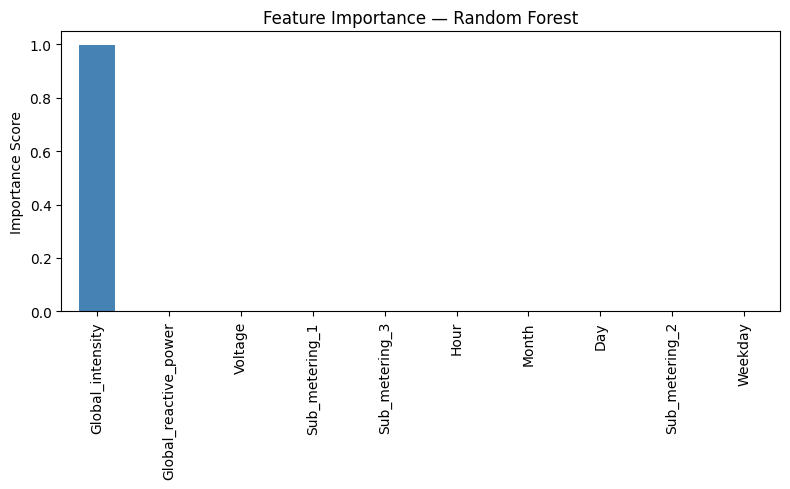

In [17]:
# ----- FEATURE IMPORTANCE (Random Forest only) -----
# Shows which features affect power consumption the most

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("Feature Importances:")
print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='steelblue')
plt.title("Feature Importance — Random Forest")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

Top 5 Peak Usage Hours (by predicted consumption):
Hour
20    1.765285
21    1.760120
19    1.602682
7     1.455529
8     1.410943
Name: Predicted, dtype: float64


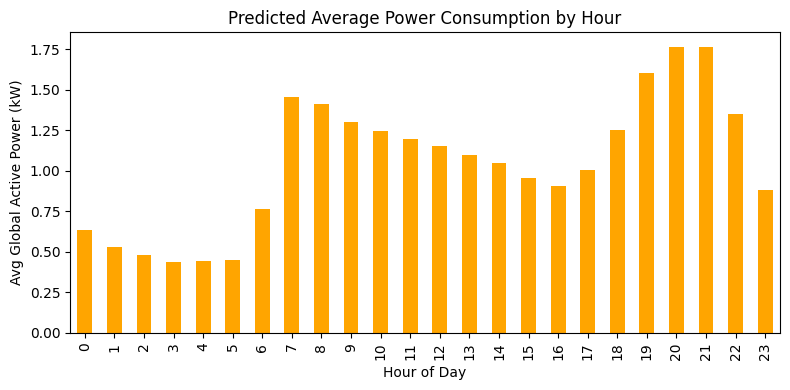

In [18]:
# ----- PEAK USAGE ANALYSIS -----
# Find the hours of the day with highest average power consumption

# Add predictions back to test data for analysis
test_df = X_test.copy()
test_df['Actual']    = y_test.values
test_df['Predicted'] = rf_pred

# Average predicted consumption per hour
peak_hours = test_df.groupby('Hour')['Predicted'].mean().sort_values(ascending=False)

print("Top 5 Peak Usage Hours (by predicted consumption):")
print(peak_hours.head())

plt.figure(figsize=(8, 4))
test_df.groupby('Hour')['Predicted'].mean().plot(kind='bar', color='orange')
plt.title("Predicted Average Power Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Global Active Power (kW)")
plt.tight_layout()
plt.show()

─── Model Comparison ───
            Model      MAE     RMSE  R2 Score
Linear Regression 0.088357 0.198385  0.953099
    Random Forest 0.015411 0.028659  0.999021


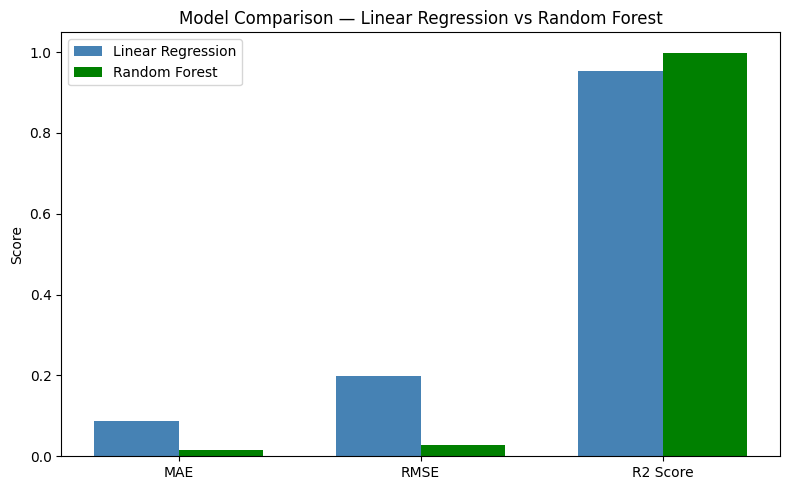

In [19]:
# ----- MODEL COMPARISON -----

comparison = pd.DataFrame({
    "Model"  : ["Linear Regression", "Random Forest"],
    "MAE"    : [lr_mae,  rf_mae],
    "RMSE"   : [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2,  rf_r2]
})

print("----- Model Comparison -----")
print(comparison.to_string(index=False))

# Bar chart comparison
metrics = ['MAE', 'RMSE', 'R2 Score']
lr_vals = [lr_mae, lr_rmse, lr_r2]
rf_vals = [rf_mae, rf_rmse, rf_r2]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, lr_vals, width, label='Linear Regression', color='steelblue')
plt.bar(x + width/2, rf_vals, width, label='Random Forest',     color='green')
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Comparison — Linear Regression vs Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# -----------------------------------------------
#       MODEL 3: K-NEAREST NEIGHBOUR
# -----------------------------------------------
# Classification of data to determine that the given house falls in which category in terms of their usage

df['usage_class'] = pd.qcut(
    df['Global_active_power'], q=3, labels=['Low', 'Medium', 'High']
)

X = df[['Hour', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']]

y = df['usage_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)


----- KNN Results -----

KNN Accuracy: 0.9575558244846971

Classification Report:
               precision    recall  f1-score   support

        High       0.98      0.98      0.98    135919
         Low       0.95      0.96      0.95    136905
      Medium       0.94      0.93      0.94    137032

    accuracy                           0.96    409856
   macro avg       0.96      0.96      0.96    409856
weighted avg       0.96      0.96      0.96    409856



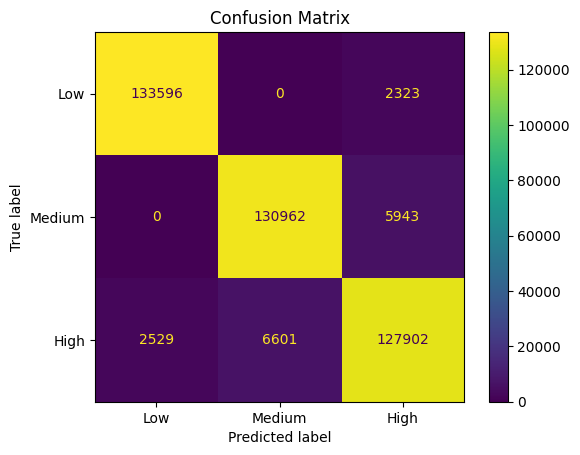

In [23]:
# KNN EVALUATIONS

print("\n----- KNN Results -----")

print("\nKNN Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nClassification Report:\n",classification_report(y_test, y_pred_knn))

# KNN PLOT
cm = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm, display_labels=['Low','Medium','High']).plot()
plt.title("Confusion Matrix")
plt.show()